In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [5]:
df = pd.read_csv("cleaned_artworks.csv")
print(f"Original shape: {df.shape}")
df.head(30)

Original shape: (87775, 11)


,Title,Artist,ConstituentID,Nationality,Gender,Date,Classification,Department,ObjectID,URL,ThumbnailURL
0,"Ferdinandsbrücke Project, Vienna, Austria (Ele...",Otto Wagner,6210,Austrian,Male,1896,Architecture,Architecture & Design,2,http://www.moma.org/collection/works/2,http://www.moma.org/media/W1siZiIsIjU5NDA1Il0s...
1,"City of Music, National Superior Conservatory ...",Christian de Portzamparc,7470,French,Male,1987,Architecture,Architecture & Design,3,http://www.moma.org/collection/works/3,http://www.moma.org/media/W1siZiIsIjk3Il0sWyJw...
2,"Villa near Vienna Project, Outside Vienna, Aus...",Emil Hoppe,7605,Austrian,Male,1903,Architecture,Architecture & Design,4,http://www.moma.org/collection/works/4,http://www.moma.org/media/W1siZiIsIjk4Il0sWyJw...
3,"Villa, project, outside Vienna, Austria, Exter...",Emil Hoppe,7605,Austrian,Male,1903,Architecture,Architecture & Design,6,http://www.moma.org/collection/works/6,http://www.moma.org/media/W1siZiIsIjEyNiJdLFsi...
4,"Memorial to the Six Million Jewish Martyrs, pr...",Louis I. Kahn,2964,American,Male,1968,Architecture,Architecture & Design,32,http://www.moma.org/collection/works/32,http://www.moma.org/media/W1siZiIsIjE3MyJdLFsi...
5,"Royal Hunting Tent, project, Exterior perspective",Marcel Kammerer,7607,Austrian,Male,1900,Architecture,Architecture & Design,34,http://www.moma.org/collection/works/34,http://www.moma.org/media/W1siZiIsIjIwMiJdLFsi...
6,"House in Krems, project, Krems, Austria, Eleva...",Otto Schönthal,7608,Austrian,Male,1905,Architecture,Architecture & Design,36,http://www.moma.org/collection/works/36,http://www.moma.org/media/W1siZiIsIjIzMyJdLFsi...
7,"Imperial Post Office, Teschen, Austria (Elevat...",Otto Schönthal,7608,Austrian,Male,1906,Architecture,Architecture & Design,39,http://www.moma.org/collection/works/39,NaN
8,"Concert Hall Project, Dresden, Germany (Interi...",Hans Poelzig,8100,German,Male,1918,Architecture,Architecture & Design,76,http://www.moma.org/collection/works/76,http://www.moma.org/media/W1siZiIsIjE2NjgxMCJd...
9,"Earth-Cloud House, project",Raimund Abraham,47,American,Male,1970,Architecture,Architecture & Design,79,http://www.moma.org/collection/works/79,http://www.moma.org/media/W1siZiIsIjUyNyJdLFsi...


In [10]:
df['Gender'] = df['Gender'].replace({'female': 'Female', 'male': 'Male'})

### Annual Artwork Acquisition Trends

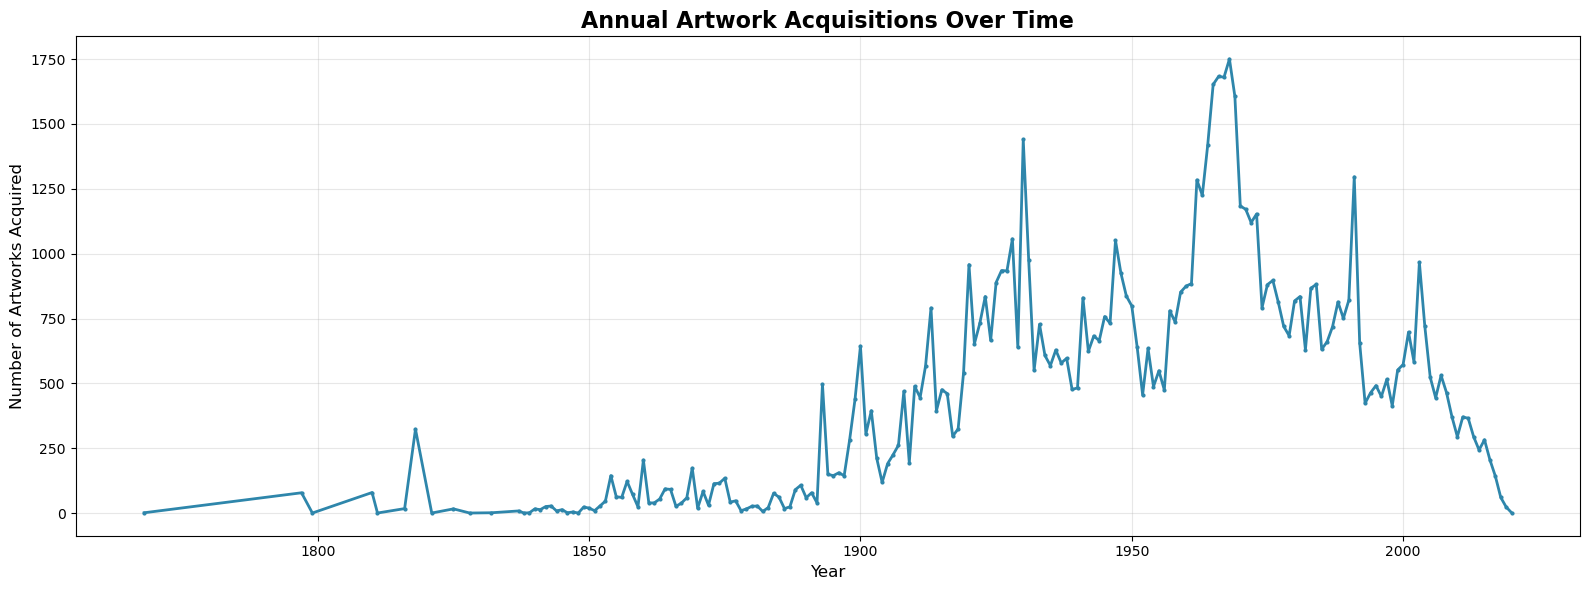

In [29]:
# Count artworks by year and sort chronologically
yearly_counts = df.groupby('Date').size().reset_index(name='Count')
yearly_counts = yearly_counts.sort_values('Date')

# Create single line chart
plt.figure(figsize=(16, 6))
plt.plot(yearly_counts['Date'], yearly_counts['Count'], 
         color='#2E86AB', linewidth=2, marker='o', markersize=2)

plt.title('Annual Artwork Acquisitions Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Artworks Acquired', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Geographic Distribution of Artworks Over Time

<Figure size 1600x800 with 0 Axes>

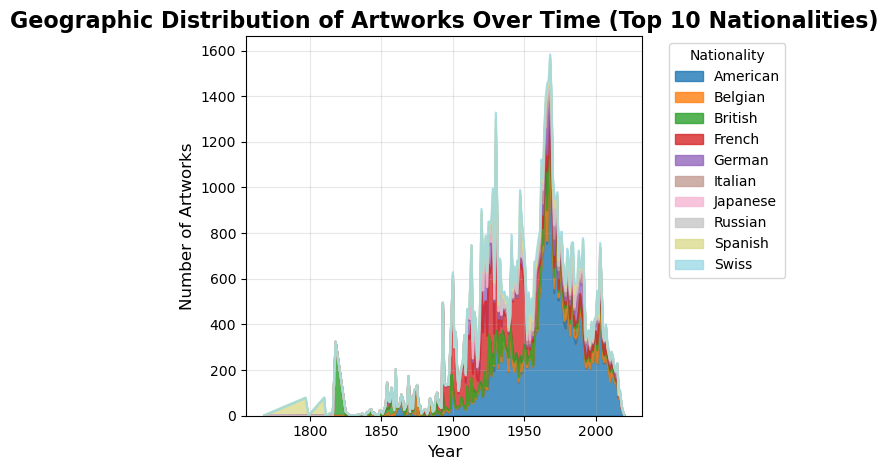


Top 10 Nationalities by Artwork Count:
Nationality
American    36859
French      17796
German       6706
British      4803
Spanish      2619
Italian      2199
Russian      1858
Japanese     1677
Swiss        1445
Belgian      1105
Name: count, dtype: int64


In [15]:
# Calculate artwork counts by nationality and year
geo_time_dist = df.groupby(['Nationality', 'Date']).size().reset_index(name='Count')

# Get top 10 nationalities
top_nats = df['Nationality'].value_counts().head(10).index.tolist()
df_top_nats = geo_time_dist[geo_time_dist['Nationality'].isin(top_nats)]

# Create pivot table and plot
pivot_data = df_top_nats.pivot_table(index='Date', columns='Nationality', values='Count', fill_value=0)

plt.figure(figsize=(16, 8))
pivot_data.plot.area(stacked=True, alpha=0.8, colormap='tab20')
plt.title('Geographic Distribution of Artworks Over Time (Top 10 Nationalities)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Artworks', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Nationality')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary
print("\nTop 10 Nationalities by Artwork Count:")
print(df['Nationality'].value_counts().head(10))

### Geographic Distribution of Artists Over Time

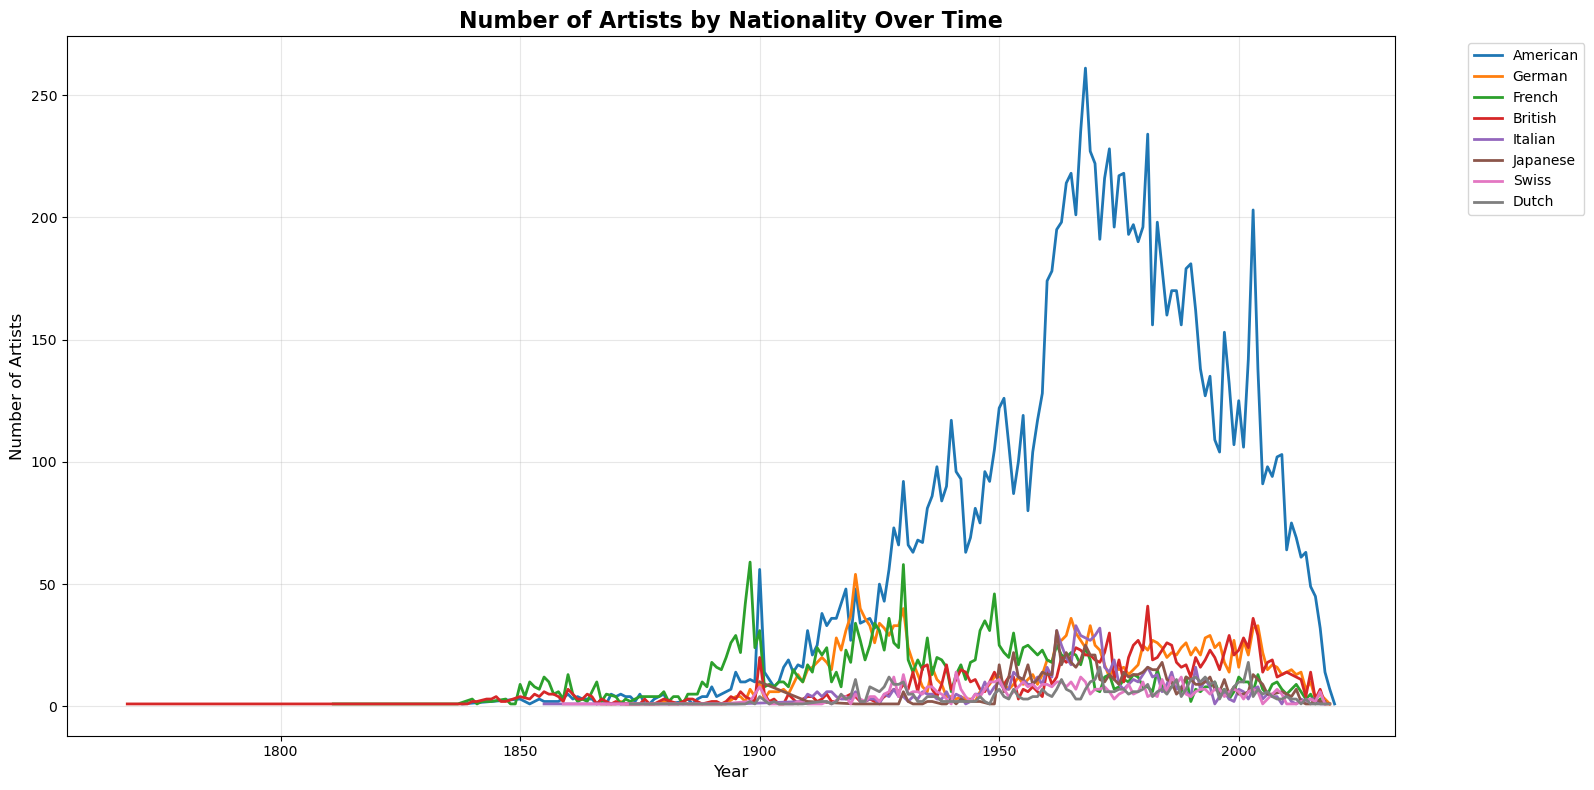


Top 10 Nationalities by Artist Count:
Nationality
American    4053
German       666
French       634
British      631
Italian      385
Japanese     354
Swiss        217
Dutch        203
Russian      201
Austrian     174
Name: Artist, dtype: int64


In [19]:
# Count unique artists by nationality and year
artist_geo = df.groupby(['Date', 'Nationality'])['Artist'].nunique().reset_index(name='Artist_Count')

# Get top 10 nationalities by artist count
top_artist_nats = df.groupby('Nationality')['Artist'].nunique().sort_values(ascending=False).head(10).index.tolist()
df_top_artists = artist_geo[artist_geo['Nationality'].isin(top_artist_nats)]

# Create pivot table and plot heatmap
pivot_artists = df_top_artists.pivot_table(index='Date', columns='Nationality', values='Artist_Count', fill_value=0)

plt.figure(figsize=(16, 8))
for nationality in top_artist_nats[:8]:
    data = df_top_artists[df_top_artists['Nationality'] == nationality]
    plt.plot(data['Date'], data['Artist_Count'], label=nationality, linewidth=2)

plt.title('Number of Artists by Nationality Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Artists', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary
print("\nTop 10 Nationalities by Artist Count:")
print(df.groupby('Nationality')['Artist'].nunique().sort_values(ascending=False).head(10))

### Gender Distribution of Artists Over Time

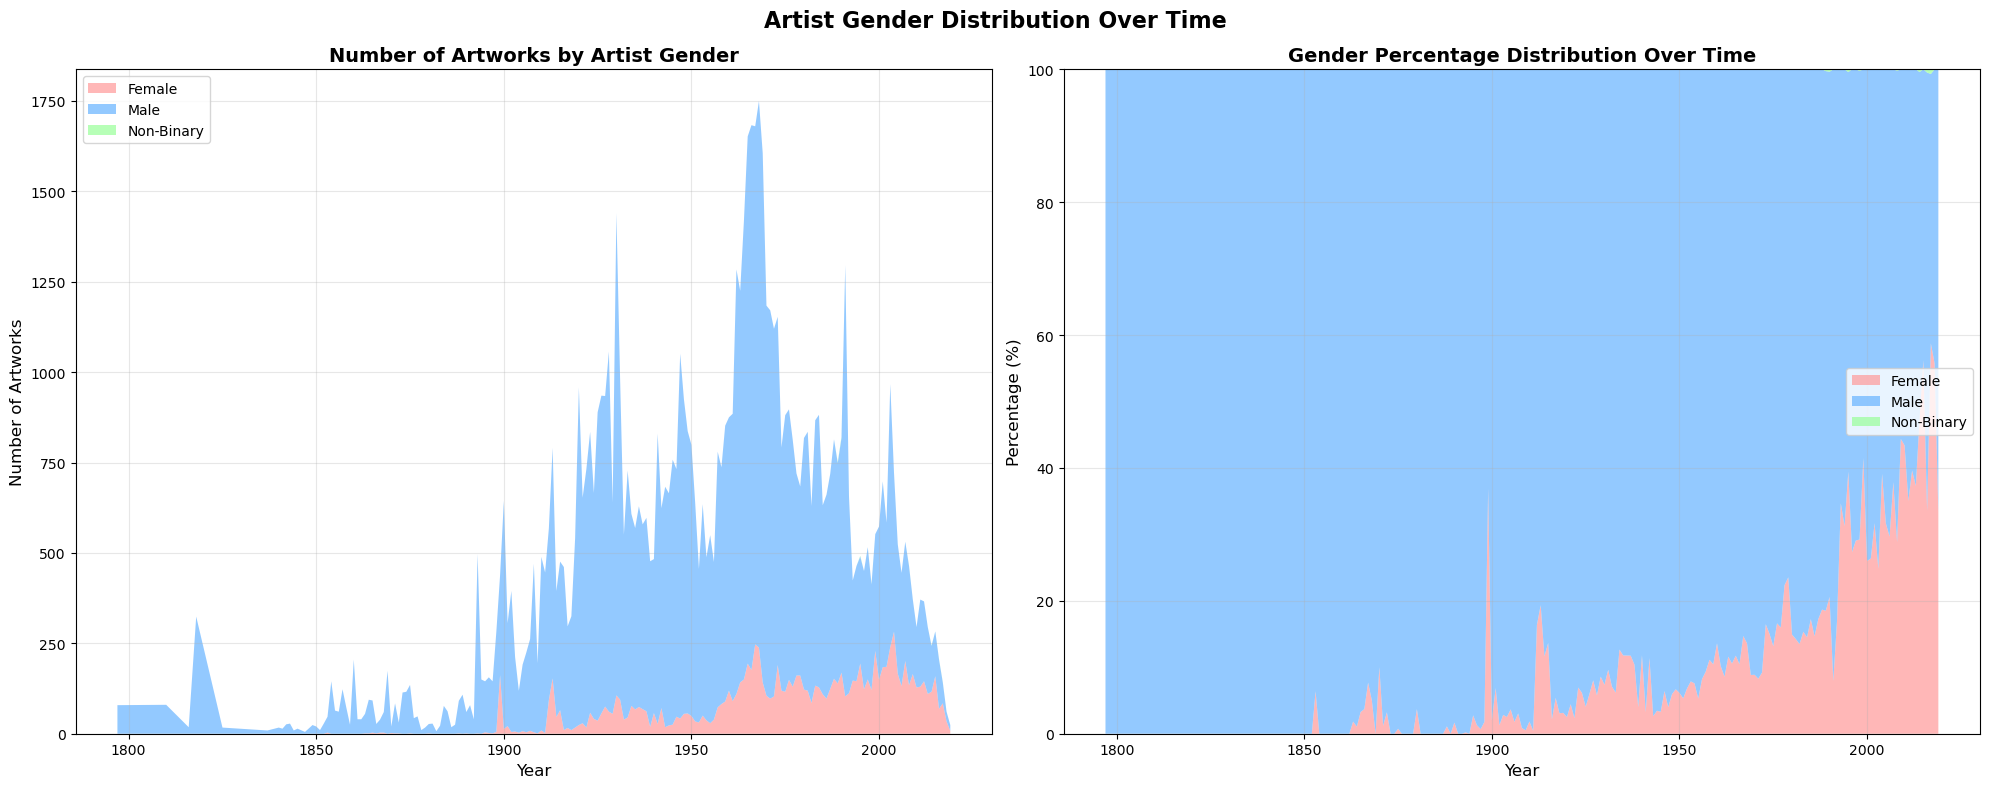


GENDER DISTRIBUTION SUMMARY
Male: 76574 (87.24%)
Female: 11189 (12.75%)
Non-Binary: 12 (0.01%)


In [21]:
# Include all gender categories (Female, Male, Non-Binary)
df_gender = df[df['Gender'].notna()].copy()  # Keep all non-null genders

# Calculate gender distribution by year
gender_by_year = df_gender.groupby(['Date', 'Gender']).size().reset_index(name='Count')
gender_pivot = gender_by_year.pivot_table(index='Date', columns='Gender', values='Count', fill_value=0)

# Get all gender categories present in data
gender_categories = gender_pivot.columns.tolist()
colors = {'Female': '#ff9999', 'Male': '#66b3ff', 'Non-Binary': '#99ff99'}

# Calculate percentages
gender_pivot['Total'] = gender_pivot.sum(axis=1)

# Filter years with sufficient data (at least 5 total artworks)
gender_filtered = gender_pivot[gender_pivot['Total'] >= 5].copy()

# Calculate percentages for each gender
for gender in gender_categories:
    gender_filtered[f'{gender}_Pct'] = (gender_filtered[gender] / gender_filtered['Total']) * 100

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Stacked area chart (absolute numbers)
ax1.stackplot(gender_filtered.index, 
              *[gender_filtered[gender] for gender in gender_categories],
              labels=gender_categories,
              colors=[colors.get(g, '#cccccc') for g in gender_categories],
              alpha=0.7)
ax1.set_title('Number of Artworks by Artist Gender', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Artworks', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Percentage over time (stacked area)
ax2.stackplot(gender_filtered.index, 
              *[gender_filtered[f'{gender}_Pct'] for gender in gender_categories],
              labels=gender_categories,
              colors=[colors.get(g, '#cccccc') for g in gender_categories],
              alpha=0.7)
ax2.set_title('Gender Percentage Distribution Over Time', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Percentage (%)', fontsize=12)
ax2.set_ylim(0, 100)
ax2.legend(loc='center right')
ax2.grid(True, alpha=0.3)

plt.suptitle('Artist Gender Distribution Over Time', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("GENDER DISTRIBUTION SUMMARY")
print("="*60)
total_gender = df_gender['Gender'].value_counts()
for gender in total_gender.index:
    percentage = (total_gender[gender] / len(df_gender)) * 100
    print(f"{gender}: {total_gender[gender]} ({percentage:.2f}%)")

### Classification Percentage Changes Over Time

Total unique classifications: 32
Top 10 classifications:
Classification
Illustrated Book    24147
Print               19359
Photograph          16840
Design               8086
Drawing              8086
Video                2131
Painting             1838
Architecture         1433
Sculpture            1287
Multiple              880
Name: count, dtype: int64

Decades with data:
[1790, 1810, 1820, 1830, 1840, 1850, 1860, 1870, 1880, 1890, 1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010]

Data shape: (22, 8)


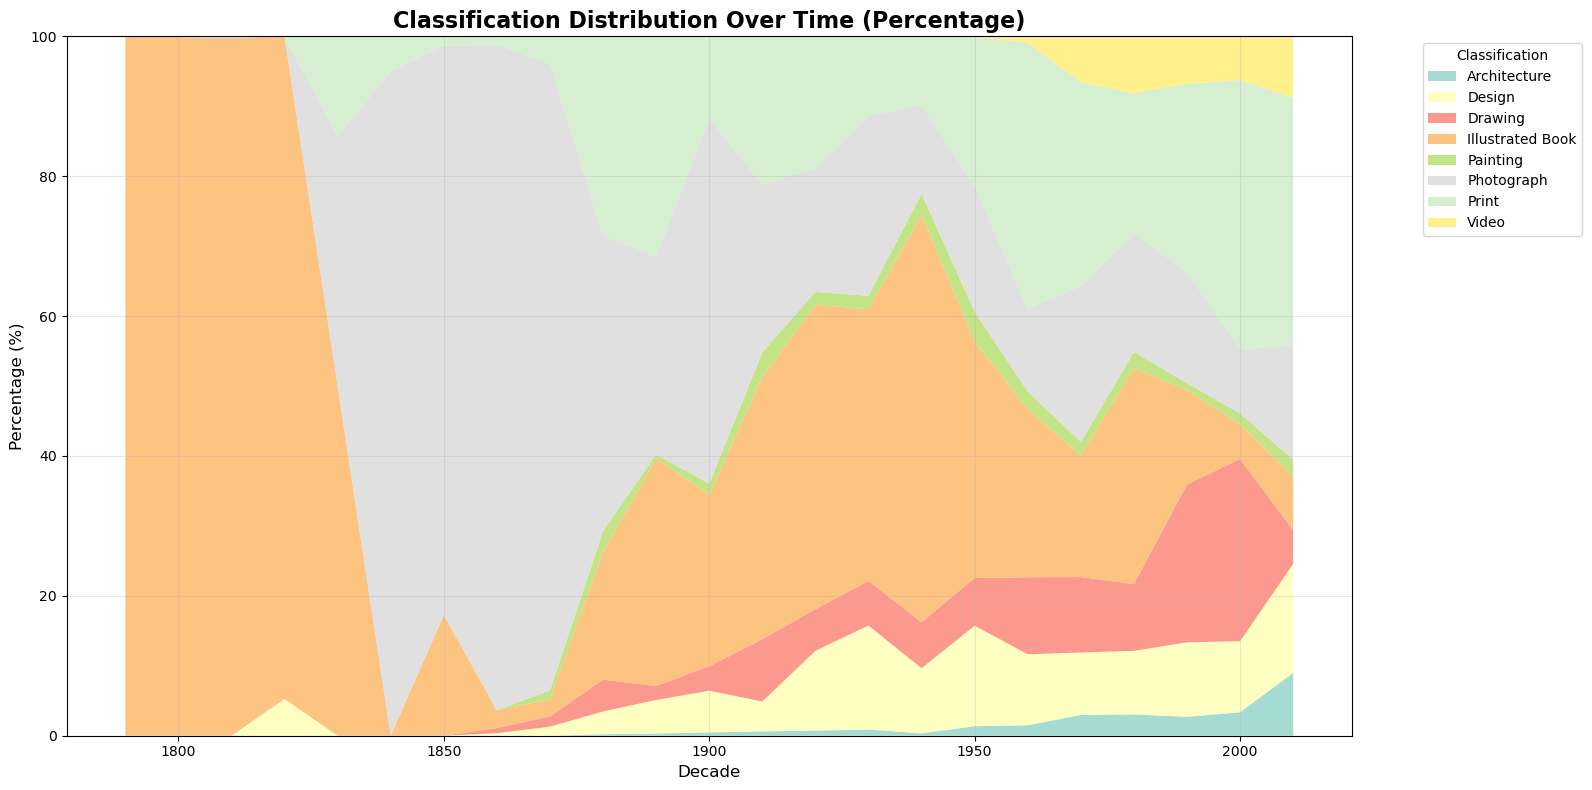


Classification Distribution by Decade (%):
Classification  Architecture  Design  Drawing  Illustrated Book  Painting  \
Decade                                                                      
1790                    0.00    0.00     0.00            100.00      0.00   
1810                    0.00    0.00     0.00             99.76      0.00   
1820                    0.00    5.26     0.00             94.74      0.00   
1830                    0.00    0.00     0.00             50.00      0.00   
1840                    0.00    0.00     0.00              0.00      0.00   
1850                    0.00    0.00     0.00             17.28      0.00   
1860                    0.00    0.36     0.73              2.54      0.00   
1870                    0.00    1.30     1.46              2.43      1.30   
1880                    0.22    3.25     4.56             18.22      3.04   
1890                    0.31    4.80     1.99             32.53      0.56   
1900                    0.47    

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ensure Date is numeric
df['Date'] = pd.to_numeric(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
df['Date'] = df['Date'].astype(int)

# Create decade
df['Decade'] = (df['Date'] // 10) * 10

# Get ALL classifications (not just top 8)
all_classes = df['Classification'].value_counts().index.tolist()
print(f"Total unique classifications: {len(all_classes)}")
print("Top 10 classifications:")
print(df['Classification'].value_counts().head(10))

# Use top 8 for visualization
top_classes = df['Classification'].value_counts().head(8).index.tolist()
df_class = df[df['Classification'].isin(top_classes)]

# Calculate percentages by decade
class_by_decade = pd.crosstab(df_class['Decade'], df_class['Classification'], normalize='index') * 100

# Filter decades with sufficient data
decade_counts = df.groupby('Decade').size()
valid_decades = decade_counts[decade_counts >= 5].index
class_by_decade = class_by_decade[class_by_decade.index.isin(valid_decades)]

print("\nDecades with data:")
print(class_by_decade.index.tolist())
print("\nData shape:", class_by_decade.shape)

# Create stacked area chart only if we have data
if not class_by_decade.empty:
    plt.figure(figsize=(16, 8))
    colors = plt.cm.Set3(np.linspace(0, 1, len(class_by_decade.columns)))
    
    plt.stackplot(class_by_decade.index, 
                  class_by_decade.values.T,
                  labels=class_by_decade.columns.tolist(),
                  colors=colors,
                  alpha=0.8)
    
    plt.title('Classification Distribution Over Time (Percentage)', fontsize=16, fontweight='bold')
    plt.xlabel('Decade', fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.ylim(0, 100)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Classification')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\nClassification Distribution by Decade (%):")
    print(class_by_decade.round(2))
else:
    print("No valid data for visualization")

### Analysis by Department (Collection Areas)


Total unique departments: 8
Department value counts:
Department
Drawings & Prints                        53796
Photography                              16450
Architecture & Design                    10517
Painting & Sculpture                      3024
Media and Performance                     2348
Film                                      1092
Fluxus Collection                          537
Architecture & Design - Image Archive       11
Name: count, dtype: int64

Department data shape: (22, 8)


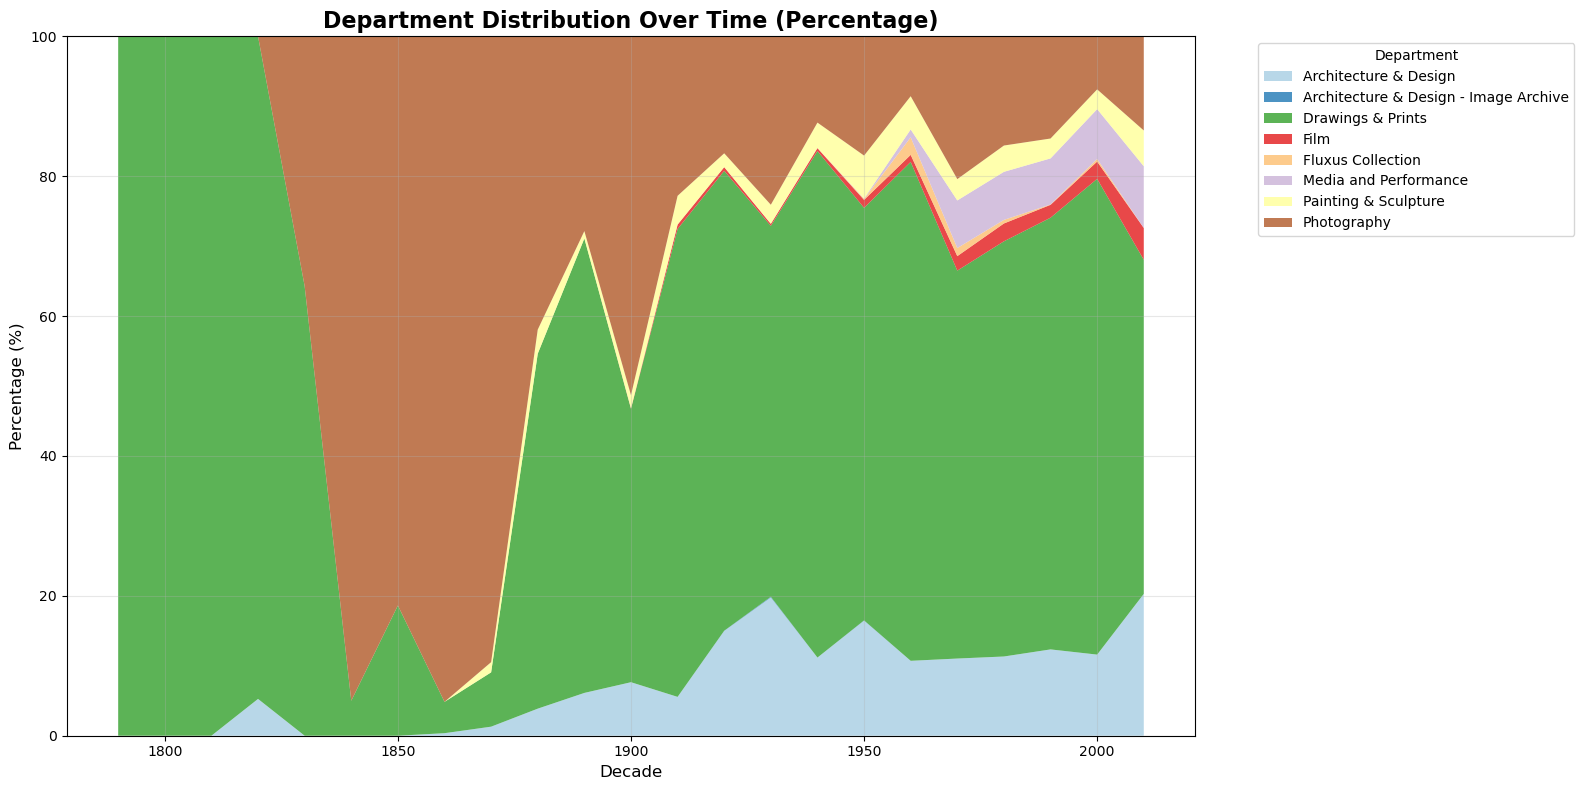


Department Distribution by Decade (%):
Department  Architecture & Design  Architecture & Design - Image Archive  \
Decade                                                                     
1790                         0.00                                   0.00   
1810                         0.00                                   0.00   
1820                         5.26                                   0.00   
1830                         0.00                                   0.00   
1840                         0.00                                   0.00   
1850                         0.00                                   0.00   
1860                         0.36                                   0.00   
1870                         1.29                                   0.00   
1880                         3.87                                   0.00   
1890                         6.12                                   0.00   
1900                         7.65               

In [28]:
# Get ALL departments
all_depts = df['Department'].value_counts().index.tolist()
print(f"\nTotal unique departments: {len(all_depts)}")
print("Department value counts:")
print(df['Department'].value_counts())

# Use top 8 for visualization
top_depts = df['Department'].value_counts().head(8).index.tolist()
df_dept = df[df['Department'].isin(top_depts)]

# Calculate percentages by decade
dept_by_decade = pd.crosstab(df_dept['Decade'], df_dept['Department'], normalize='index') * 100

# Filter decades with sufficient data
dept_by_decade = dept_by_decade[dept_by_decade.index.isin(valid_decades)]

print("\nDepartment data shape:", dept_by_decade.shape)

if not dept_by_decade.empty:
    plt.figure(figsize=(16, 8))
    colors = plt.cm.Paired(np.linspace(0, 1, len(dept_by_decade.columns)))
    
    plt.stackplot(dept_by_decade.index, 
                  dept_by_decade.values.T,
                  labels=dept_by_decade.columns.tolist(),
                  colors=colors,
                  alpha=0.8)
    
    plt.title('Department Distribution Over Time (Percentage)', fontsize=16, fontweight='bold')
    plt.xlabel('Decade', fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.ylim(0, 100)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Department')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\nDepartment Distribution by Decade (%):")
    print(dept_by_decade.round(2))